In [36]:
import sys
sys.modules.pop("src.segmentation_border", None)
sys.modules.pop("src.segmentation_edges", None)
from src.segmentation_border import *
from src.utils import rgb2hsv, apply_colour_threshold
from src.config import load_config, set_global_config
config = load_config("config.json")
set_global_config(config)

# Card Segmentation Pipeline

**Overview:** This notebook demonstrates the end-to-end card segmentation pipeline, which isolates individual card images for downstream classification and analysis.

**Objective:** Extract isolated, properly-oriented card images from image, enabling accurate downstream analysis of card properties and content.

**Methodology:** The pipeline employs a multi-stage approach combining color-based detection, morphological operations, and geometric transformations to reliably identify and extract card boundaries from complex backgrounds.

In [16]:
img_path = "data/train_images/L1000910.jpg"

# show the image
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_hsv = rgb2hsv(img_rgb)

## Stage 1: White Border Detection

**Purpose**: Identify card boundaries by detecting the white background regions that typically frame cards in photographs.

**Approach**:
- HSV-based color thresholding with parameters configured in `config.json`
- Morphological opening operation (4×4 ellipse kernel) to reduce noise and segmentation artifacts
- Produces binary mask highlighting bright background regions that form card borders

**Output**: Binary white mask used to validate and constrain subsequent color region detection

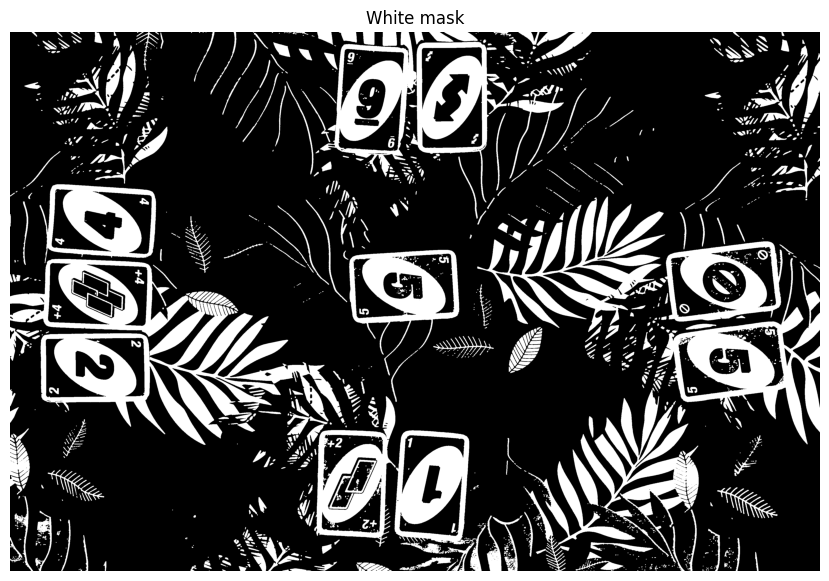

In [17]:
white_mask = get_white_mask(img_rgb, plot=True)

## Stage 2: Color Region Detection

### 2.1 Generate Color Masks

Extract individual color channels (yellow, green, blue, red, black) from the input image using HSV-based thresholding. These masks should identify the positions of the cards.

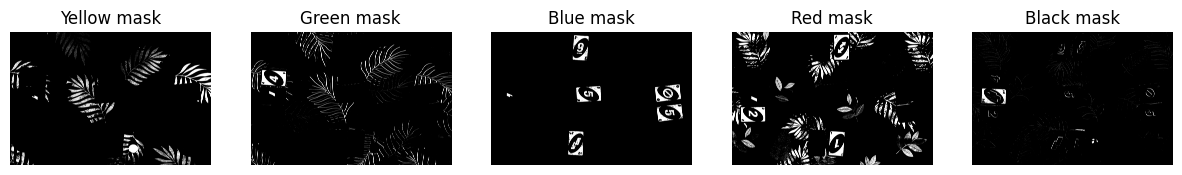

In [18]:
yellow_mask = apply_colour_threshold(img_rgb, color="y")
green_mask = apply_colour_threshold(img_rgb, color="g")
blue_mask = apply_colour_threshold(img_rgb, color="b")
red_mask = apply_colour_threshold(img_rgb, color="r")
black_mask = apply_colour_threshold(img_rgb, color="k")

# plot the masks
masks = [yellow_mask, green_mask, blue_mask, red_mask, black_mask]
titles = ["Yellow mask", "Green mask", "Blue mask", "Red mask", "Black mask"]
plt.figure(figsize=(15,10))
for i, (mask, title) in enumerate(zip(masks, titles)):
    plt.subplot(1, 5, i+1)
    plt.imshow(mask, cmap='gray')
    plt.axis("off")
    plt.title(title)
plt.show()

### 2.2 Region Detection with White Border Validation

**Objective**: Identify candidate card regions by detecting colored components with white borders.

**Algorithm**:
1. **Dilation**: Expand each color region with an ellipse kernel (border_width=20 pixels)
2. **Ring Extraction**: Subtract original region from dilated version to isolate the border area
3. **White Overlap Assessment**: Calculate what fraction of the ring overlaps with the white mask
4. **Filtering**: Retain only regions where white_ratio is over WHITE_RATIO_THRESH
5. **Contour Extraction**: Extract external contours from dilated components using cv2.findContours()
6. **Bounding Geometry**: Fit minimum area rotated rectangle to each contour with cv2.minAreaRect()

**Rationale**: Cards typically have distinct white borders; this constraint filters out noise and background artifacts while preserving true card detections.

In [19]:
all_regions = []

for color_name, mask in [
        ("yellow", yellow_mask),
        ("green", green_mask),
        ("blue", blue_mask),
        ("red", red_mask),
        ("black", black_mask)
    ]:
        regions = detect_colour_regions_with_white_border(
            img,
            white_mask,
            mask.astype(np.uint8) * 255
        )

        for r in regions:
            rect, box, score = r
            all_regions.append((rect, box, score, color_name))


20 regions detected with white border


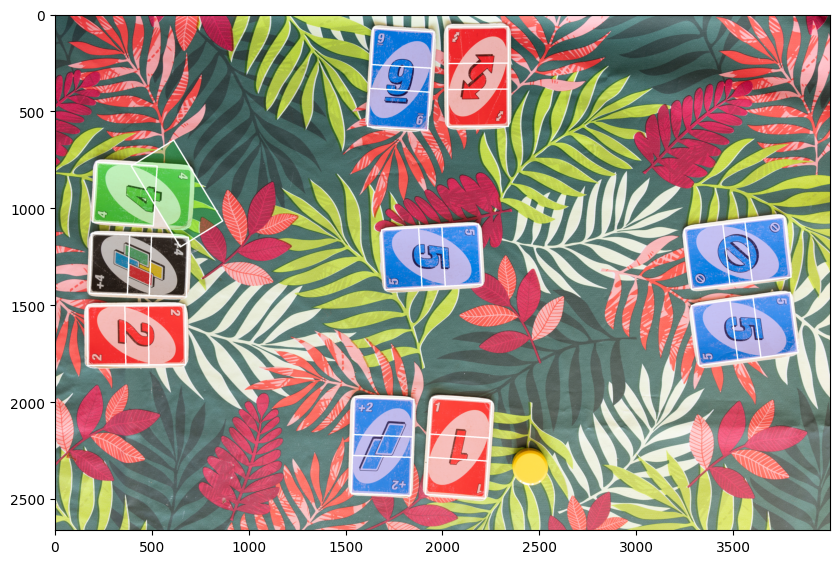

In [20]:
print(len(all_regions), "regions detected with white border")

vis = img_rgb.copy()
overlay = vis.copy()

color_map = {
    "yellow": (255, 255, 0),
    "green":  (0, 255, 0),
    "blue":   (0, 0, 255),
    "red":    (255, 0, 0),
    "black":  (0, 0, 0),
}

# draw all filled contours onto overlay first
for rect, box, score, color_name in all_regions:
    cv2.drawContours(overlay, [box], 0, color_map[color_name], cv2.FILLED)

# single blend
vis = cv2.addWeighted(overlay, 0.2, vis, 0.8, 0)

# draw borders after blending
for rect, box, score, color_name in all_regions:
    cv2.drawContours(vis, [box], 0, (255, 255, 255), 5)

plt.figure(figsize=(10, 10))
plt.imshow(vis)          # ← vis, not img_rgb
plt.axis("on")
# plt.title("Detected regions with white border")
plt.show()

## Stage 3: Region Merging

### 3.1 Merge Aligned Regions

**Objective**: Consolidate fragmented detections of the same card that may have been split across multiple color components.

**Criteria for Merging**:
- Same color classification
- Parallel or perpendicular orientation (angle_tol=1°)
- Spatial proximity (within 100 pixels, calibrated to typical distance between main card color regions)

**Outcome**: Reduces multi-detections while preserving distinct cards within the image.

In [21]:
all_regions = merge_overlapping_regions(all_regions)

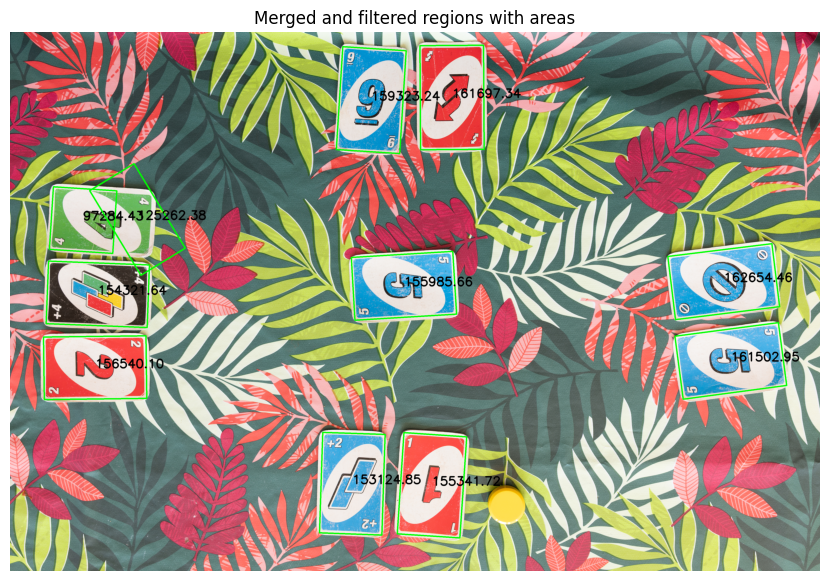

In [22]:

vis = img_rgb.copy()
for i, (rect, box, score, color_name) in enumerate(all_regions):

    area = rect[1][0] * rect[1][1]

    cv2.drawContours(image=vis, contours=[box], contourIdx=0, color=(0,255,0), thickness=5)

    cx, cy = map(int, rect[0])

    cv2.putText(
        img=vis,
        text=f"{area:.2f}",
        org=(cx, cy),
        fontFace=cv2.FONT_HERSHEY_SIMPLEX,
        fontScale=2.0,
        color=(0,0,0),
        thickness=5
    )

plt.figure(figsize=(12,7))
plt.imshow(vis)
plt.axis("off")
plt.title("Merged and filtered regions with areas")
plt.show()


### 3.2 Remove Contained Regions

**Objective**: Eliminate redundant detections and prevent duplicate extraction.

**Method**: Remove smaller regions that are completely contained within larger regions.

**Benefit**: Eliminates false positives from fragmentation while maintaining one representative detection per card.

In [23]:

all_regions = discard_contained_regions(all_regions)

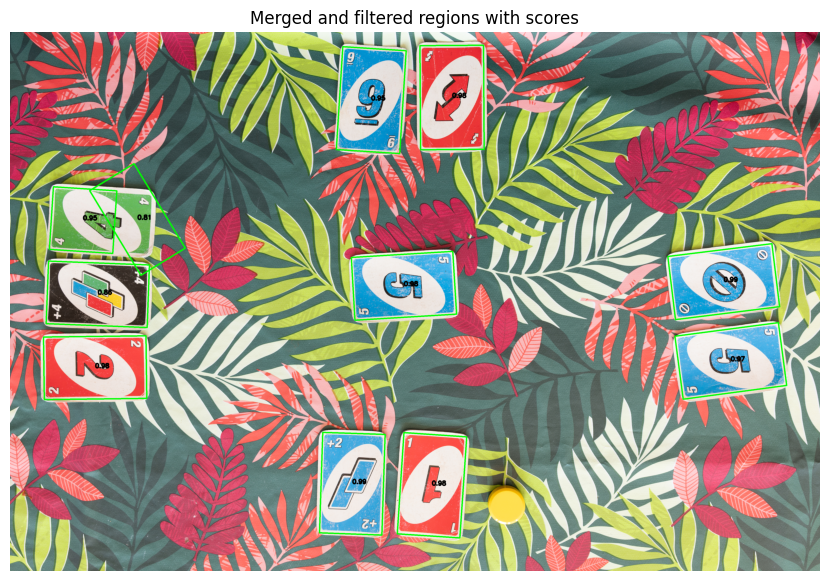

In [24]:

vis = img_rgb.copy()
for i, (rect, box, score, color_name) in enumerate(all_regions):

    cv2.drawContours(image=vis, contours=[box], contourIdx=0, color=(0,255,0), thickness=5)

    cx, cy = map(int, rect[0])

    cv2.putText(
        img=vis,
        text=f"{score:.2f}",
        org=(cx, cy),
        fontFace=cv2.FONT_HERSHEY_SIMPLEX,
        fontScale=1.0,
        color=(0,0,0),
        thickness=5
    )

plt.figure(figsize=(12,7))
plt.imshow(vis)
plt.axis("off")
plt.title("Merged and filtered regions with scores")
plt.show()


## Stage 4: Perspective Correction and Card Extraction

**Objective**: Normalize detected card regions into properly-oriented, rectangular images suitable for classification.

**Steps**:
1. **Point Ordering**: Reorder bounding box corner points consistently post-merging
2. **Dimension Calculation**: Compute width and height from corner point distances
3. **Perspective Transform**: Apply cv2.getPerspectiveTransform() to map detected quadrilateral corners to rectangular grid
4. **Orientation Normalization**: Auto-rotate if width > height to ensure upright orientation (landscape → portrait)
5. **Output**: Warped, axis-aligned card image with dimensions matching detected geometry

**Result**: Each detected card is extracted as an isolated, normalized image ready for downstream classification analysis.

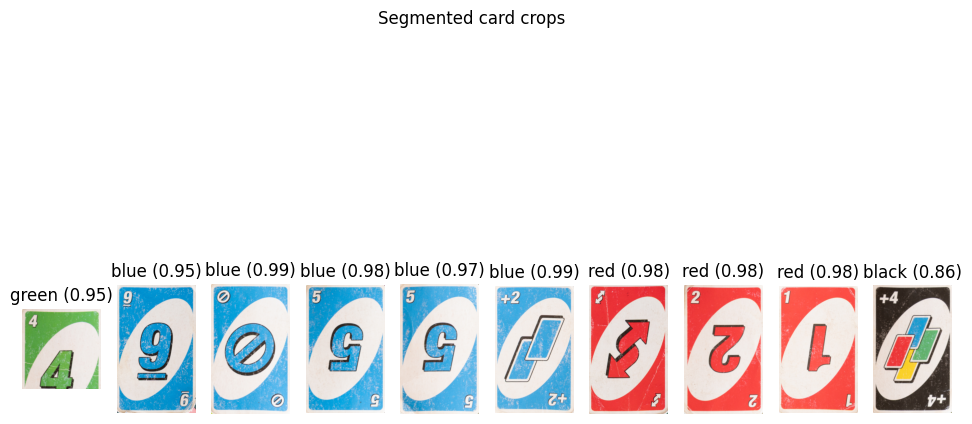

In [25]:
cards = segmented_cards(img_rgb, plot=True)